# Preconditioned global bound in the scattered-voltage basis $V_\mathrm{sca}$

Preconditioned variant of `VscatBound.ipynb`. The optimization variable is again the scattered voltage $V_\mathrm{sca} = -Z_0 I$, with the current
eliminated by the linear map $I = -W V_\mathrm{sca}$, $W = Z_0^{-1}$, but the power conservation constraints are taken in the preconditioned,
**unshifted** form (equation 38 of the AToM notes, Section *Preconditioning*),
$$\operatorname{Re}\left[I^H P^H S I - I^H P^H V_\mathrm{p}\right] = 0, \qquad V_\mathrm{p} = V_\mathrm{q} + S I_0,$$
built from the preconditioned system $S \hat I = V_\mathrm{q}$, $\hat I = I - I_0$ (equation 37), i.e. the current $I$ itself (not the shift $\hat I$)
is substituted. Since $S$ is the system matrix row-scaled by a diagonal matrix, the preconditioned constraints with projector $P$ are the
original constraints with a reweighted diagonal projector, so the global constraints ($P = \mathbf 1$, $P = j\mathbf 1$) are no longer the
real and reactive power conservation and give a different global bound, while the complete set of local constraints spans the same space.

In [1]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

In [2]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [3]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_dipole.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(r"R0_dipole.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(r"X0_dipole.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(r"V_dipole.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ v)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix

def evalObjI(Ivec):
    # radiated power in the current basis
    return(0.5*np.real(Ivec.conj().T @ R0 @ Ivec))

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObjI(Ifull) # objective for full plate
print(f"Objective for full plate: {Pfull:.6e} W")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195
Objective for full plate: 1.010821e+01 W


## Objective in $V_\mathrm{sca}$

With $I = -W V_\mathrm{sca}$ the radiated power $\tfrac12 I^H R_0 I$ takes the dolphindes form
$-x^H A_0 x + 2\operatorname{Re}(x^H s_0) + c_0$, $x = V_\mathrm{sca}$, with
$$A_0 = -\tfrac12 W^H R_0 W,\qquad s_0 = 0,\qquad c_0 = 0 .$$
The quadratic part is identical to the $V_\mathrm{tot}$ formulation.

In [4]:
print(f"cond(Z0) = {np.linalg.cond(Z0):.3e}")
W = np.linalg.inv(Z0)   # Z0^{-1}
WH = W.conj().T

Obj = -0.5 * Msym(WH @ R0 @ W)
obj = np.zeros(Ndes, dtype=complex)
obj0 = 0.0

def VtoI(Vsca):
    return(-W @ Vsca)

def evalObj(Vsca):
    return(-np.real(Vsca.conj().T @ Obj @ Vsca) + 2*np.real(Vsca.conj().T @ obj) + obj0)

Vfull = -Z0 @ Ifull # scattered voltage for full plate
print(f"Objective for full plate in Vsca: {evalObj(Vfull):.6e} W (I basis {Pfull:.6e} W)")

cond(Z0) = 1.750e+04
Objective for full plate in Vsca: 1.010821e+01 W (I basis 1.010821e+01 W)


## Preconditioner

In the Cholesky basis $Z_\rho = Z_s \mathbf 1$. Following `preconditioner.ipynb` (equivalent to the notation of the notes with
$X \to -jX$, $G \to -jG$), with the material admittance $X = Z_\rho^{-1}$, $D = \operatorname{diag}(Z_0)$, $H = Z_0 - D$,
$$Y = (\mathbf 1 + X D)^{-1} X, \qquad S = \mathbf 1 + Y H, \qquad I_0 = X V, \qquad V_\mathrm{q} = -Y Z_0 I_0, \qquad V_\mathrm{p} = V_\mathrm{q} + S I_0 ,$$
the system $Z_\mathrm{tot} I = V$ reads $S (I - I_0) = V_\mathrm{q}$, i.e. $S I = V_\mathrm{p}$. With the diagonal
$M = (\mathbf 1 + X D)^{-1}$, $S = M X Z_\mathrm{tot}$ and $V_\mathrm{p} = M X V$, so for $I = -W V_\mathrm{sca}$
$$S I - V_\mathrm{p} = -\operatorname{diag}(d)\left(V + V_\mathrm{sca} - Z_s I\right), \qquad d_i = \frac{1}{Z_s + D_{ii}} ,$$
the pointwise material relation scaled by the preconditioner weights $d$.

In [5]:
X = np.eye(Ndes)/Zs                   # material admittance Z_rho^{-1}
D = np.diag(np.diag(Z0))              # diagonal of the free-space operator
H = Z0 - D
Y = np.linalg.solve(np.eye(Ndes) + X @ D, X)
S = np.eye(Ndes) + Y @ H              # preconditioned system matrix
I0 = X @ Vinc                         # shift current Z_rho^{-1} V
Vq = -Y @ Z0 @ I0                     # shifted excitation, S (I - I0) = Vq
Vp = Vq + S @ I0                      # unshifted excitation, S I = Vp
d = 1/(Zs + np.diag(D))               # preconditioner weights

print(f"cond(S) = {np.linalg.cond(S):.3e}, cond(Ztot) = {np.linalg.cond(Ztot):.3e}")
print(f"||S Ifull - Vp||/||Vp|| = {np.linalg.norm(S @ Ifull - Vp)/np.linalg.norm(Vp):.2e}")
xRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
IRand = VtoI(xRand)
print(f"S I - Vp = -d (V + Vsca - Zs I): relative error "
      f"{np.linalg.norm(S @ IRand - Vp + d*(Vinc + xRand - Zs*IRand))/np.linalg.norm(S @ IRand - Vp):.2e}")
print(f"|d| in [{np.abs(d).min():.3e}, {np.abs(d).max():.3e}], arg(d)/pi in [{np.angle(d).min()/np.pi:.3f}, {np.angle(d).max()/np.pi:.3f}]")

cond(S) = 1.732e+04, cond(Ztot) = 1.732e+04
||S Ifull - Vp||/||Vp|| = 1.07e-10
S I - Vp = -d (V + Vsca - Zs I): relative error 3.04e-11
|d| in [8.796e-05, 9.578e-05], arg(d)/pi in [0.500, 0.500]


## Equation 38 in the shared projector form

Substituting $I = -W x$, $x = V_\mathrm{sca}$, into equation 38,
$$\operatorname{Re}\left[I^H P^H S I - I^H P^H V_\mathrm{p}\right] = \operatorname{Re}\left[x^H W^H P^H S W x + x^H W^H P^H V_\mathrm{p}\right] = 0 ,$$
without a constant term. Using $\operatorname{Re}(x^H B x) = \operatorname{Re}(x^H B^H x)$ with $B^H = W^H S^H P W$, this is exactly the dolphindes
shared projector form $\operatorname{Re}\left(-x^H A_1 P A_2 x + 2 x^H A_2^H P^H s_1\right) = 0$ with
$$A_1 = -W^H S^H, \qquad A_2 = W, \qquad s_1 = \tfrac12 V_\mathrm{p},$$
with the projector $P$ of equation 38 passed unchanged. The global constraints are $P = \mathbf 1$ and $P = j\mathbf 1$
(phase $q = P^* \in \{1, -j\}$ as in `VscatBound.ipynb`). By the relation above, equation 38 with projector $P$ equals the unpreconditioned
constraint $\operatorname{Re}\left[I^H \operatorname{diag}(p_o)(V + V_\mathrm{sca} - Z_s I)\right] = 0$ with the reweighted projector
$p_o = -P^* d$.

In [6]:
A1 = -WH @ S.conj().T
A2 = W
s1 = 0.5 * Vp

qList = [1, -1j]   # P^H = q 1
Plist = [sp.diags(np.conj(q)*np.ones(Ndes, dtype=complex)) for q in qList]

def projRes(x, P):
    # Re(-x^H A1 P A2 x + 2 x^H A2^H P^H s1)
    return(np.real(-x.conj() @ A1 @ (P @ (A2 @ x)) + 2*x.conj() @ (A2.conj().T @ (P.conj().T @ s1))))

def eq38Res(Vsca, p):
    # Re[I^H P^H (S I - Vp)] with P = diag(p), evaluated directly
    I = VtoI(Vsca)
    return(np.real(np.sum(np.conj(p)*np.conj(I)*(S @ I - Vp))))

def directRes(Vsca, p):
    # unpreconditioned Re[I^H diag(p) (V + Vsca - Zs I)]
    I = VtoI(Vsca)
    return(np.real(np.sum(p*np.conj(I)*(Vinc + Vsca - Zs*I))))

print("residuals at full plate:", [f"{projRes(Vfull, P):.2e} (eq. 38 {eq38Res(Vfull, P.diagonal()):.2e})" for P in Plist])

pRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
print(f"random P, random x: shared form {projRes(xRand, sp.diags(pRand)):.6e}, eq. 38 {eq38Res(xRand, pRand):.6e}, "
      f"reweighted unpreconditioned {directRes(xRand, -np.conj(pRand)*d):.6e}")

residuals at full plate: ['6.17e-14 (eq. 38 6.12e-14)', '-9.98e-14 (eq. 38 -9.98e-14)']
random P, random x: shared form -6.529596e-05, eq. 38 -6.529596e-05, reweighted unpreconditioned -6.529596e-05


## Dual problem

Unlike the unpreconditioned case, no closed-form dual feasible point is available, since the global constraint matrices
$\operatorname{Sym}(A_1 P A_2) = -W^H \operatorname{Sym}(S^H P) W$ are congruent to the row-scaled $Z_\mathrm{tot}$. A feasible starting point is
found by scanning the complex combination $\lambda_1 + j\lambda_2$ over phase and magnitude for the largest minimum eigenvalue of $A(\lambda)$.

In [7]:
QCQP = DenseSharedProjQCQP(Obj, obj, obj0, A1, s1, Plist, A2=A2, verbose=1)

Acon = [Msym(A1 @ P @ A2) for P in Plist]
def minEig(lags):
    return np.min(np.linalg.eigvalsh(Obj + sum(l*A for l, A in zip(lags, Acon))))

scan = [r*np.array([np.cos(th), np.sin(th)]) for th in np.linspace(0, 2*np.pi, 73)[:-1] for r in np.logspace(-1, 5, 31)]
eigScan = np.array([minEig(l) for l in scan])
lags_init = scan[np.argmax(eigScan)]
print(f"initial lags {lags_init}, minimum eigenvalue {eigScan.max():.3e}, dual feasible: {QCQP.is_dual_feasible(lags_init)}")

opt_params = OptimizationHyperparameters(opttol=1e-6,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=10,
    penalty_ratio=1e-2,
    penalty_reduction=0.1,
    break_iter_period=5,
    verbose=0)

t1 = time.time()
result = QCQP.solve_current_dual_problem(method='newton', init_lags=lags_init, opt_params=opt_params)
print(f"bound: {result[0]:.6e} W, time: {time.time()-t1:.2f}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 2 A matrices and Fs vectors.
initial lags [-99619.46980917  -8715.57427477], minimum eigenvalue 4.204e-04, dual feasible: True
bound: 1.021926e+01 W, time: 0.14s, Lagrange multipliers: [  -952.27769691 -11259.09338584]


In [8]:
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(totalA))):.3e}")

Vstar = QCQP.current_xstar
Istar = VtoI(Vstar)
print(f"dual bound {QCQP.current_dual:.6e} W, P(x*) {evalObj(Vstar):.6e} W (I basis {evalObjI(Istar):.6e} W), full plate {Pfull:.6e} W")
print("constraint residuals at x*:", [f"{projRes(Vstar, P):.2e}" for P in Plist])
print("real/reactive power conservation at x*:", [f"{directRes(Vstar, q*np.ones(Ndes)):.2e}" for q in qList])

minimum eigenvalue of A: 4.019e-06
dual bound 1.021926e+01 W, P(x*) 1.021926e+01 W (I basis 1.021926e+01 W), full plate 1.010821e+01 W
constraint residuals at x*: ['-2.15e-11', '1.83e-12']
real/reactive power conservation at x*: ['-1.65e-01', '-6.70e-02']


## Reference: unpreconditioned bounds

1. The preconditioned global constraints written as unpreconditioned constraints with the reweighted projectors $p_o = -P^* d$
   (shared projector form of `VscatBound.ipynb`, $A_1 = 1 + Z_s^* W^H$, $A_2 = W$, $s_1 = -\tfrac12 V$, $P' = \operatorname{diag}(p_o^*)$)
   must give the same bound.
2. The plain global real and reactive power constraints ($p_o = \mathbf 1$, $-j\mathbf 1$) of `VscatBound.ipynb` give a different bound.

In [9]:
B1 = np.eye(Ndes) + np.conj(Zs) * WH
t1v = -0.5 * Vinc

PlistW = [sp.diags(np.conj(-np.conj(P.diagonal())*d)) for P in Plist]   # P' = diag(p_o^*), p_o = -P^* d
QCQP_W = DenseSharedProjQCQP(Obj, obj, obj0, B1, t1v, PlistW, A2=W, verbose=0)
resultW = QCQP_W.solve_current_dual_problem(method='newton', init_lags=lags, opt_params=opt_params)
print(f"reweighted unpreconditioned bound: {resultW[0]:.6e} W, preconditioned: {result[0]:.6e} W, "
      f"relative difference {abs(resultW[0]-result[0])/result[0]:.2e}")

PlistU = [sp.diags(np.conj(q)*np.ones(Ndes, dtype=complex)) for q in qList]
QCQP_U = DenseSharedProjQCQP(Obj, obj, obj0, B1, t1v, PlistU, A2=W, verbose=0)
resultU = QCQP_U.solve_current_dual_problem(method='newton', init_lags=np.array([1.0, 0.0]), opt_params=opt_params)
print(f"unpreconditioned global bound (VscatBound.ipynb): {resultU[0]:.6e} W, preconditioned global bound: {result[0]:.6e} W")

reweighted unpreconditioned bound: 1.021926e+01 W, preconditioned: 1.021926e+01 W, relative difference 1.09e-10
unpreconditioned global bound (VscatBound.ipynb): 1.012093e+01 W, preconditioned global bound: 1.021926e+01 W


## Local projector constraints by GCD

The local constraints share $A_1$, $A_2$, $s_1$ with the global ones and are generated by `dolphindes.cvxopt.gcd.run_gcd` as in
`VscatBound.ipynb`. The strongest-violation projector $p_i = (2s_1 - A_1^H x^\star)_i (A_2 x^\star)_i^*$ now equals the pointwise violation
of equation 38, $I_i^{\star *}(S I^\star - V_\mathrm{p})_i = -d_i\, I_i^{\star *}(V + V^\star_\mathrm{sca} - Z_s I^\star)_i$, i.e. the physical
pointwise violation weighted by the preconditioner.

In [20]:
import copy
from dolphindes.cvxopt.gcd import GCDHyperparameters

Ngcd = 40   # number of GCD iterations, each adds a max violation and a min eigenvalue projector

gQCQP = copy.deepcopy(QCQP)
gQCQP.verbose = 0
gcd_params = GCDHyperparameters(max_proj_cstrt_num=2 + 2*Ngcd,
    max_gcd_iter_num=Ngcd,
    gcd_iter_period=Ngcd + 1,   # no early termination
    opt_params=opt_params)

def localViolation(Vsca):
    # pointwise w_i = I_i^* (V + Vsca - Zs I)_i, zero for any physical structure
    I = VtoI(Vsca)
    return(np.conj(I)*(Vinc + Vsca - Zs*I))

t1 = time.time()
gQCQP.run_gcd(gcd_params)
print(f"bound: {QCQP.current_dual:.6e} -> {gQCQP.current_dual:.6e} W (full plate {Pfull:.6e} W), "
      f"{gQCQP.n_proj_constr} projectors, {time.time()-t1:.2f}s")

At GCD iteration #1, best dual bound found is             10.21925992335405.
min eigenvalue: 4.019375e-06
At GCD iteration #2, best dual bound found is             10.219066057086293.
min eigenvalue: 4.019329e-06
At GCD iteration #3, best dual bound found is             10.21849799608496.
min eigenvalue: 4.019318e-06
At GCD iteration #4, best dual bound found is             10.216850655233696.
min eigenvalue: 4.019372e-06
At GCD iteration #5, best dual bound found is             10.213736886595456.
min eigenvalue: 4.019354e-06
At GCD iteration #6, best dual bound found is             10.209428832496714.
min eigenvalue: 4.018973e-06
At GCD iteration #7, best dual bound found is             10.206037302932597.
min eigenvalue: 4.018418e-06
At GCD iteration #8, best dual bound found is             10.205955326667711.
min eigenvalue: 4.018586e-06
At GCD iteration #9, best dual bound found is             10.205949021762148.
min eigenvalue: 4.018558e-06
At GCD iteration #10, best dual bound f

minimum eigenvalue of A: 4.018e-06
dual bound 1.020557e+01 W, P(x*) 1.019270e+01 W
max |constraint residual| at x*: 2.41e-05 (global), 1.32e-01 (all)
||local violation||: global 2.601e+00, GCD 7.645e+00


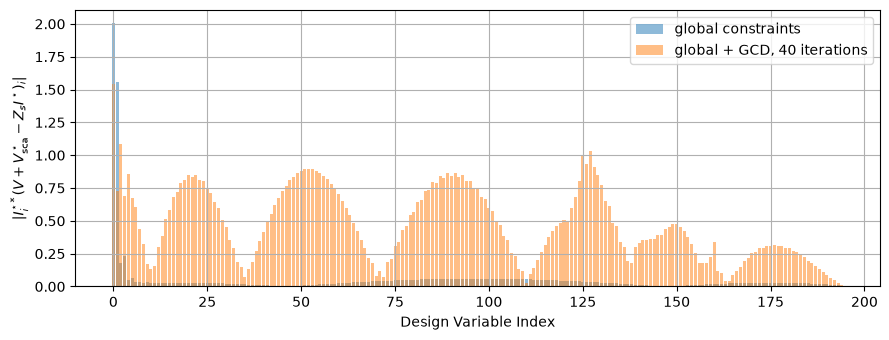

In [21]:
import matplotlib.pyplot as plt

Vstar = gQCQP.current_xstar
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(gQCQP._get_total_A(gQCQP.current_lags)))):.3e}")
print(f"dual bound {gQCQP.current_dual:.6e} W, P(x*) {evalObj(Vstar):.6e} W")
PlistG = gQCQP.Proj.get_Pdata_column_stack()
print(f"max |constraint residual| at x*: {max(abs(projRes(Vstar, P)) for P in Plist):.2e} (global), "
      f"{max(abs(projRes(Vstar, sp.diags(PlistG[:, j]))) for j in range(PlistG.shape[1])):.2e} (all)")
print(f"||local violation||: global {np.linalg.norm(localViolation(QCQP.current_xstar)):.3e}, "
      f"GCD {np.linalg.norm(localViolation(Vstar)):.3e}")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(np.arange(Ndes), np.abs(localViolation(QCQP.current_xstar)), alpha=0.5, label='global constraints')
ax.bar(np.arange(Ndes), np.abs(localViolation(Vstar)), alpha=0.5, label=f'global + GCD, {Ngcd} iterations')
ax.set_xlabel('Design Variable Index'); ax.set_ylabel(r'$|I^{\star *}_i(V + V^\star_\mathrm{sca} - Z_s I^\star)_i|$')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

## Inferred complex material density

Material density per basis function (as in `densityConstraintsImag.ipynb`), from the total voltage $V + V_\mathrm{sca}$,
$$\rho_i = \frac{Z_s I_i}{V_i + V_{\mathrm{sca},i}}, \qquad I = -W V_\mathrm{sca},$$
equal to 1 on material and 0 on empty basis functions for a physical structure.

global constraints: Re rho in [-0.211, 0.843], Im rho in [-0.104, 0.958], ||Im rho||/||rho|| 7.183e-01
global + GCD, 40 iterations: Re rho in [-0.097, 0.032], Im rho in [-0.029, 0.080], ||Im rho||/||rho|| 6.750e-01


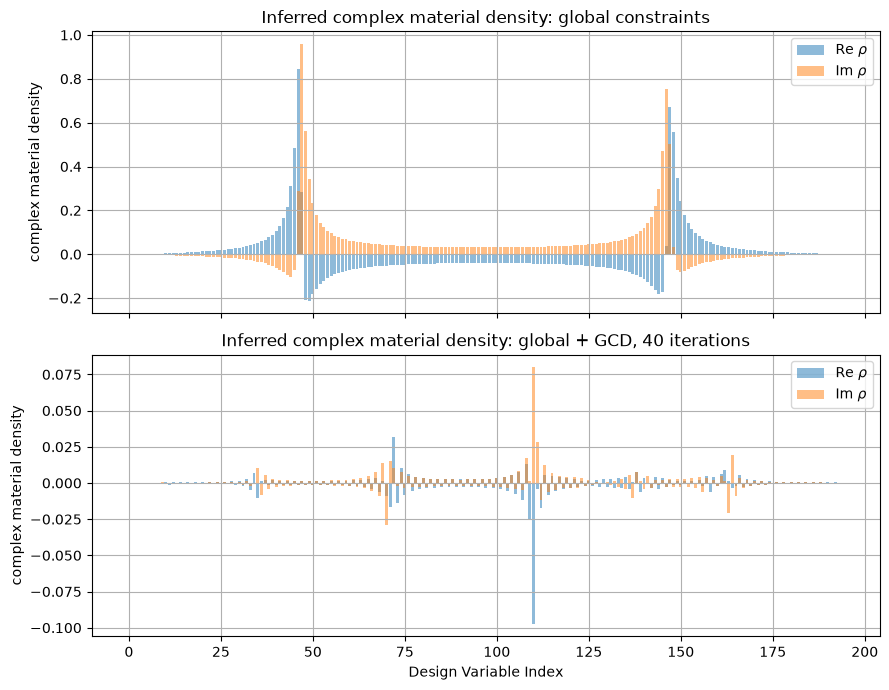

In [22]:
def complexDensity(Vsca):
    # inferred complex material density rho = Zs I / (V + Vsca) (Cholesky space)
    return Zs*VtoI(Vsca)/(Vinc + Vsca)

rhoGlob = complexDensity(QCQP.current_xstar)    # global constraints
rhoLoc = complexDensity(gQCQP.current_xstar)    # after Ngcd GCD iterations
cases = [("global constraints", rhoGlob), (f"global + GCD, {Ngcd} iterations", rhoLoc)]
for name, rho in cases:
    print(f"{name}: Re rho in [{rho.real.min():.3f}, {rho.real.max():.3f}], "
          f"Im rho in [{rho.imag.min():.3f}, {rho.imag.max():.3f}], ||Im rho||/||rho|| {np.linalg.norm(rho.imag)/np.linalg.norm(rho):.3e}")

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for ax, (name, rho) in zip(axes, cases):
    ax.bar(np.arange(Ndes), np.real(rho), alpha=0.5, label=r'Re $\rho$')
    ax.bar(np.arange(Ndes), np.imag(rho), alpha=0.5, label=r'Im $\rho$')
    ax.set_ylabel('complex material density'); ax.set_title(f'Inferred complex material density: {name}')
    ax.legend(); ax.grid(True)
axes[-1].set_xlabel('Design Variable Index')
plt.tight_layout(); plt.show()

## Inference optimization over the material density $\rho$

The ratio above gives a complex $\rho$ with no bounds. A physical structure needs a real $\rho_i \in [0, 1]$ such that the current is that
of the material excited by the total field, $I_i = \rho_i\, Z_s^{-1} E_{\mathrm{tot},i}$ with $E_\mathrm{tot} = V + V_\mathrm{sca}$.
The density is therefore inferred from the fit
$$\min_{\rho\in[0,1]^N} \left\| \operatorname{diag}(\rho)\, Z_s^{-1} E_\mathrm{tot} - I \right\|^2, \qquad I = -W V_\mathrm{sca},$$
which separates over the basis functions. With $b_i = E_{\mathrm{tot},i}/Z_s$ the minimizer is the projection onto the box
$$\rho_i = \operatorname{clip}\!\left(\frac{\operatorname{Re}(b_i^* I_i)}{|b_i|^2},\, 0,\, 1\right).$$
The design is then checked by solving the physical problem $(Z_s + \operatorname{diag}(\rho) Z_0)\, I = \operatorname{diag}(\rho)\, V$
and by a threshold sweep for a binary structure.

In [23]:
def fitDensity(Vsca):
    # argmin_{rho in [0,1]^N} || rho Etot/Zs - I ||, separable: projection of the pointwise least squares solution
    b = (Vinc + Vsca)/Zs
    I = VtoI(Vsca)
    rho = np.clip(np.real(np.conj(b)*I)/np.abs(b)**2, 0, 1)
    res = np.linalg.norm(rho*b - I)/np.linalg.norm(I)
    return rho, res

def realizedObj(rho):
    # radiated power of the structure with density rho: (Zs + diag(rho) Z0) I = diag(rho) V
    S = np.diag(rho.astype(complex))
    I = np.linalg.solve(Zs*np.eye(Ndes) + S @ Z0, S @ Vinc)
    return evalObjI(I)

rhoFull, resFull = fitDensity(Vfull)
print(f"full plate check: rho in [{rhoFull.min():.6f}, {rhoFull.max():.6f}], relative fit residual {resFull:.2e}")

ths = np.linspace(0.05, 0.95, 19)
fits = {}
print(f"dual bound: global {QCQP.current_dual:.6e} W, GCD {gQCQP.current_dual:.6e} W, full plate {Pfull:.6e} W")
for name, Vs in [("global constraints", QCQP.current_xstar), (f"global + GCD, {Ngcd} iterations", gQCQP.current_xstar)]:
    rho, res = fitDensity(Vs)
    Pbin = np.array([realizedObj((rho > t).astype(float)) for t in ths])
    fits[name] = (rho, Pbin)
    print(f"{name}: relative fit residual {res:.3e}, mean density {rho.mean():.3f}, "
          f"realized objective {realizedObj(rho):.6e} W, best binary {Pbin.max():.6e} W (threshold {ths[np.argmax(Pbin)]:.2f})")

full plate check: rho in [1.000000, 1.000000], relative fit residual 3.93e-10
dual bound: global 1.021926e+01 W, GCD 1.020557e+01 W, full plate 1.010821e+01 W
global constraints: relative fit residual 9.232e-01, mean density 0.033, realized objective 3.946417e-04 W, best binary 4.655820e-07 W (threshold 0.05)
global + GCD, 40 iterations: relative fit residual 8.786e-01, mean density 0.001, realized objective 5.730840e-08 W, best binary 0.000000e+00 W (threshold 0.05)


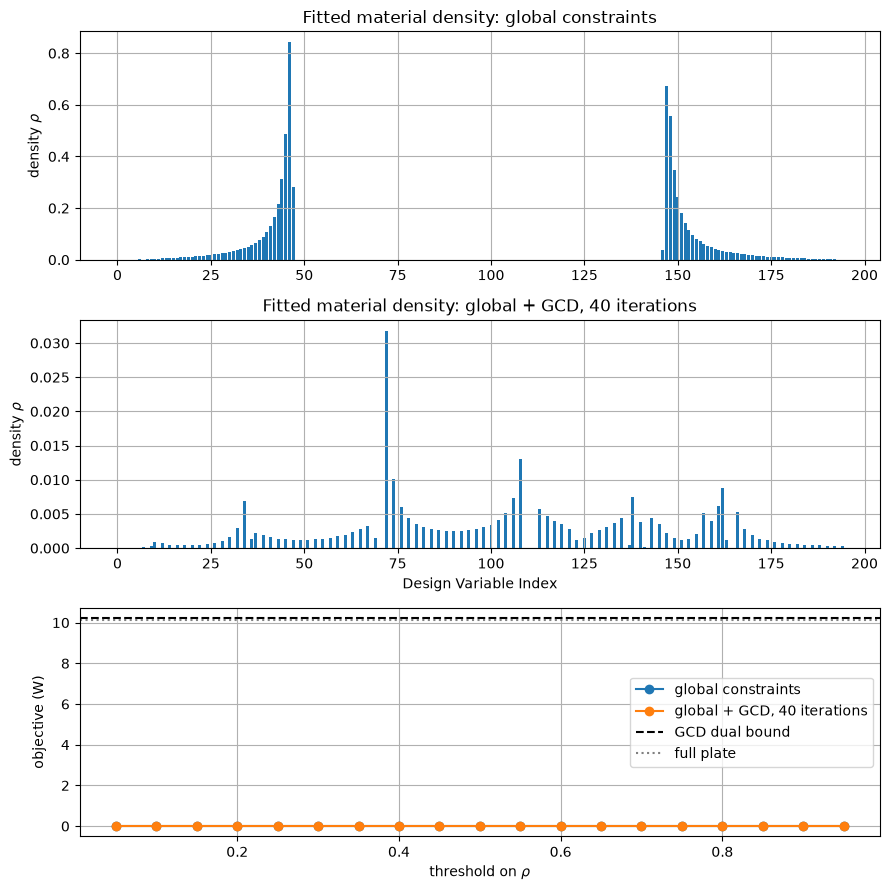

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9))
for ax, (name, (rho, _)) in zip(axes[:2], fits.items()):
    ax.bar(np.arange(Ndes), rho)
    ax.set_ylabel(r'density $\rho$'); ax.set_title(f'Fitted material density: {name}'); ax.grid(True)
axes[1].set_xlabel('Design Variable Index')
for name, (_, Pbin) in fits.items():
    axes[2].plot(ths, Pbin, 'o-', label=name)
axes[2].axhline(gQCQP.current_dual, ls='--', c='k', label='GCD dual bound')
axes[2].axhline(Pfull, ls=':', c='gray', label='full plate')
axes[2].set_xlabel(r'threshold on $\rho$'); axes[2].set_ylabel('objective (W)'); axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()